In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.callbacks import EarlyStopping

from statsmodels.tsa.arima.model import ARIMA

import yfinance as yf
import math
import warnings
warnings.filterwarnings("ignore")

In [2]:
stocks = {
    "Oracle": "ORCL",
    "ICICI": "ICICIBANK.NS",
    "Britannia": "BRITANNIA.NS",
    "Maruti": "MARUTI.NS",
    "AbbottIndia": "ABBOTINDIA.NS"
}


In [3]:
all_stock_data = {}

start_date = "2021-01-01"
end_date = "2025-12-31"

for name, ticker in stocks.items():
    print(f"Downloading data for {name} ({ticker})")

    df = yf.download(ticker, start=start_date, end=end_date)

    # Keep only Close price
    df = df[["Close"]].dropna()

    all_stock_data[name] = df

    print(f"{name}: {df.shape[0]} rows loaded\n")

print("All stocks downloaded successfully")

[*********************100%***********************]  1 of 1 completed


Oracle: 1254 rows loaded



[*********************100%***********************]  1 of 1 completed


ICICI: 1235 rows loaded



[*********************100%***********************]  1 of 1 completed


Britannia: 1235 rows loaded



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Maruti: 1235 rows loaded

AbbottIndia: 1235 rows loaded

All stocks downloaded successfully


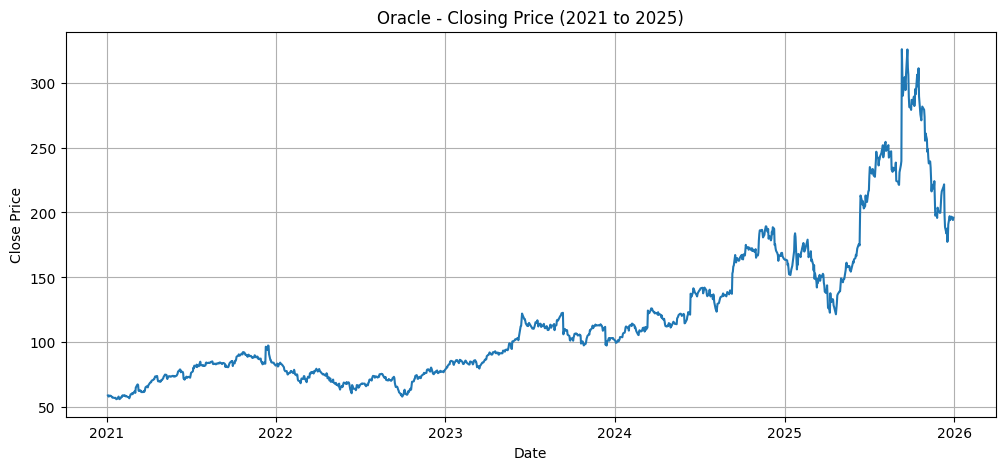

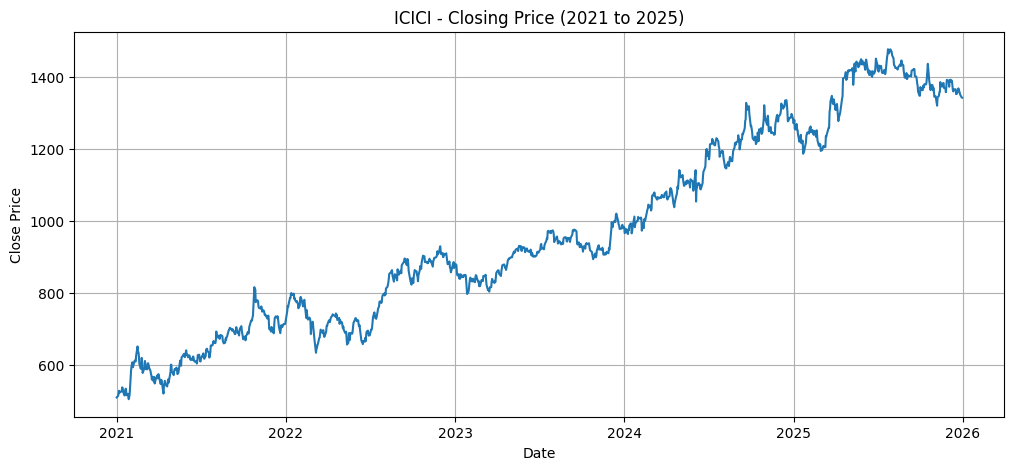

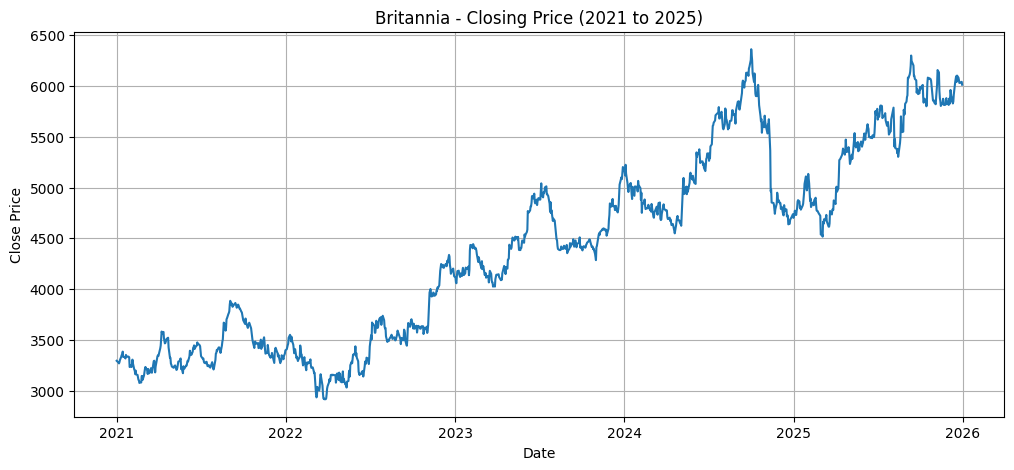

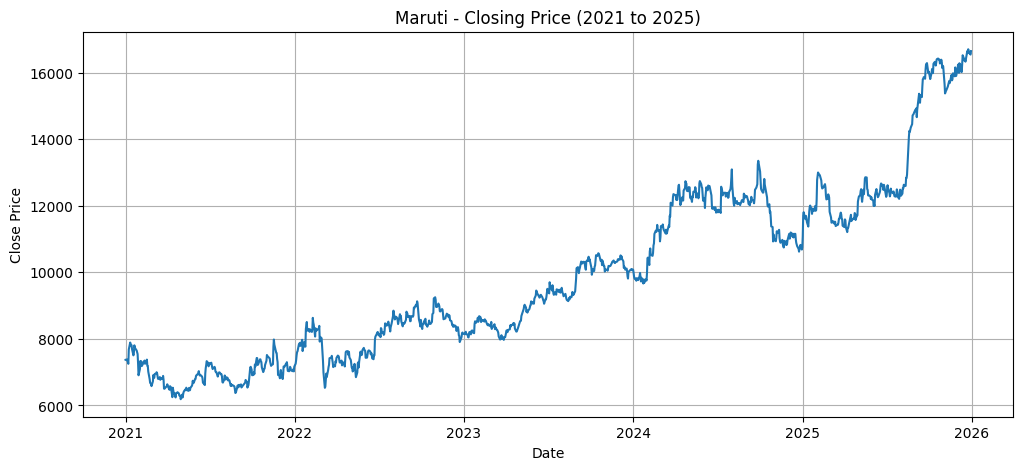

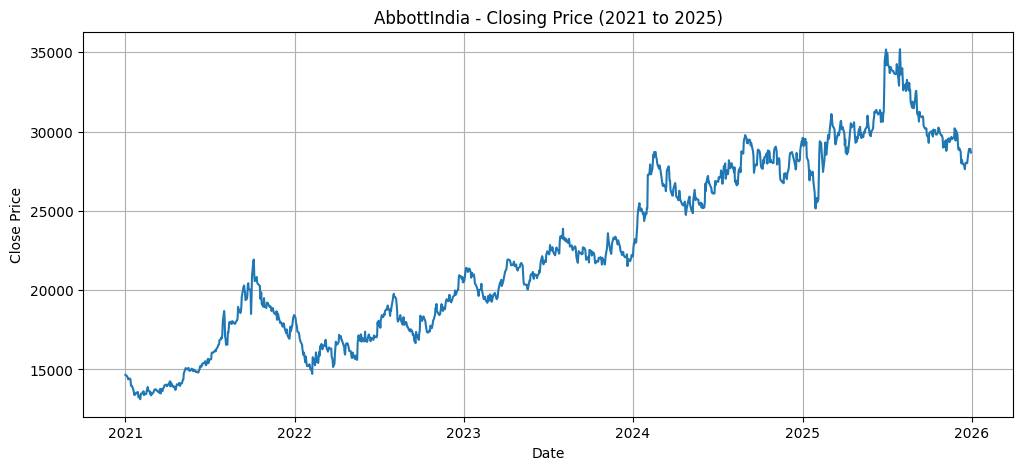

In [4]:
for name, df in all_stock_data.items():
    plt.figure(figsize=(12, 5))
    plt.plot(df.index, df["Close"])
    plt.title(f"{name} - Closing Price (2021 to 2025)")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.grid(True)
    plt.show()

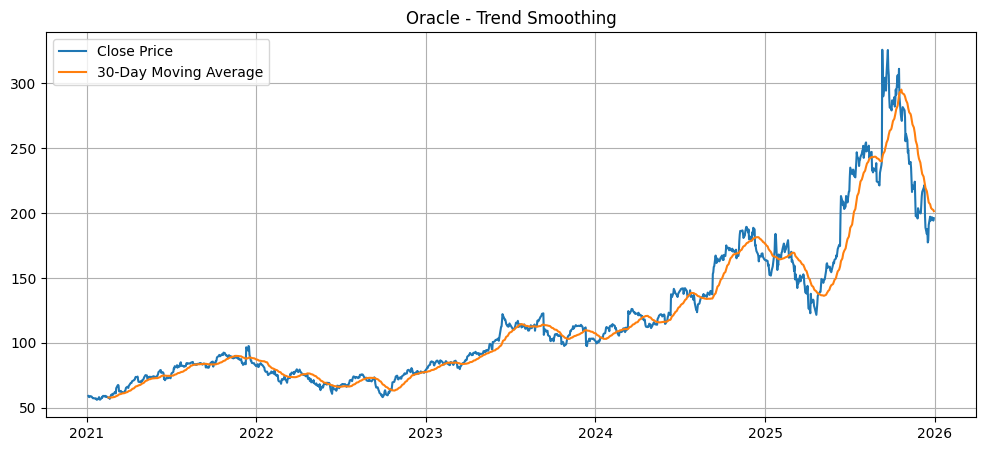

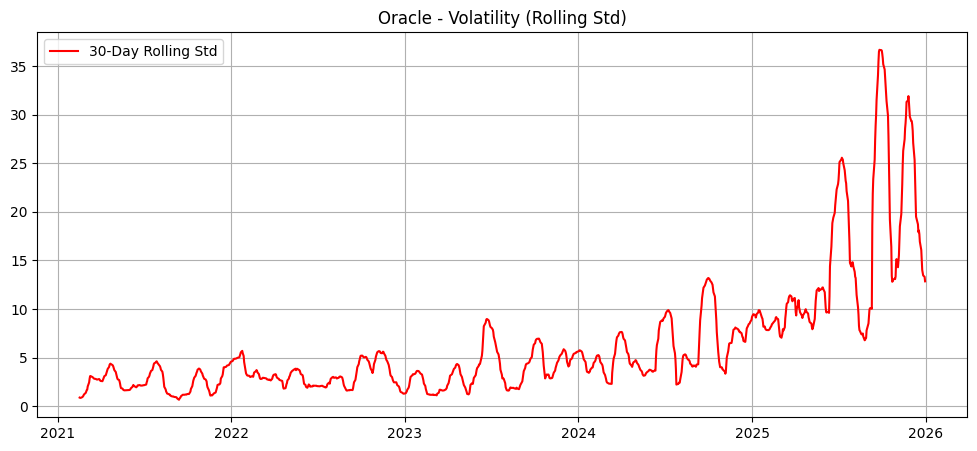

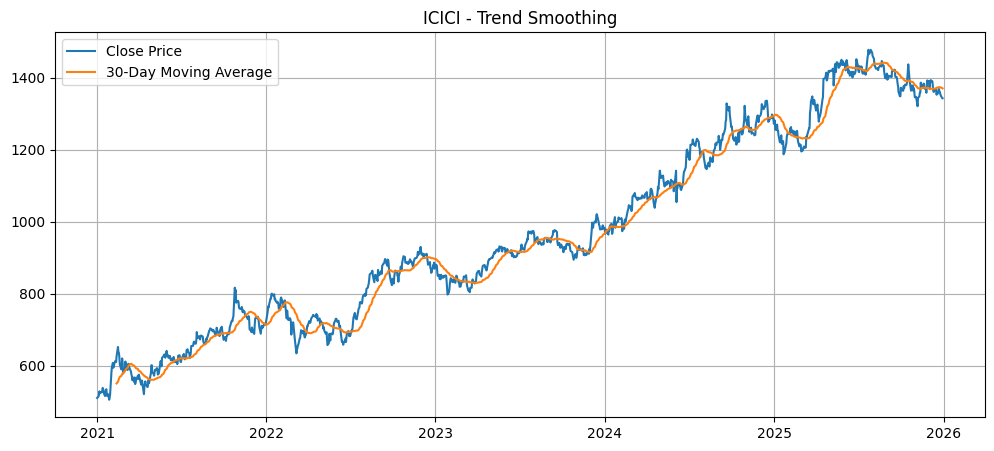

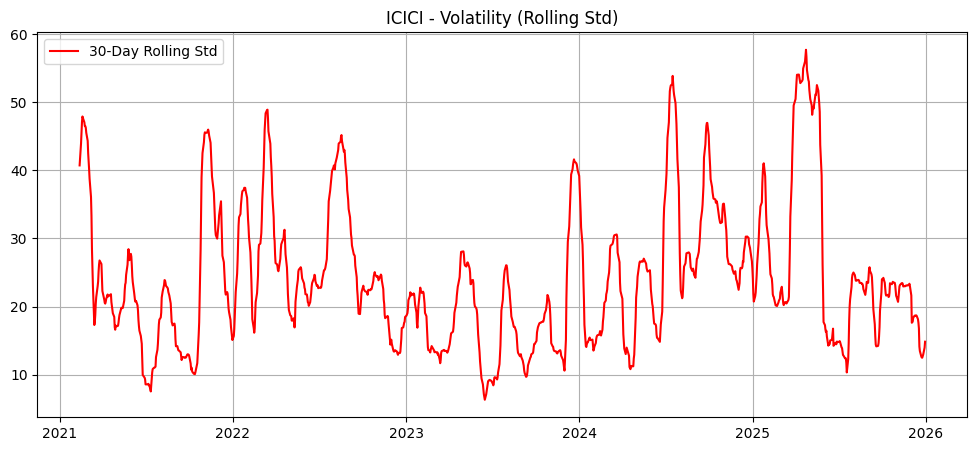

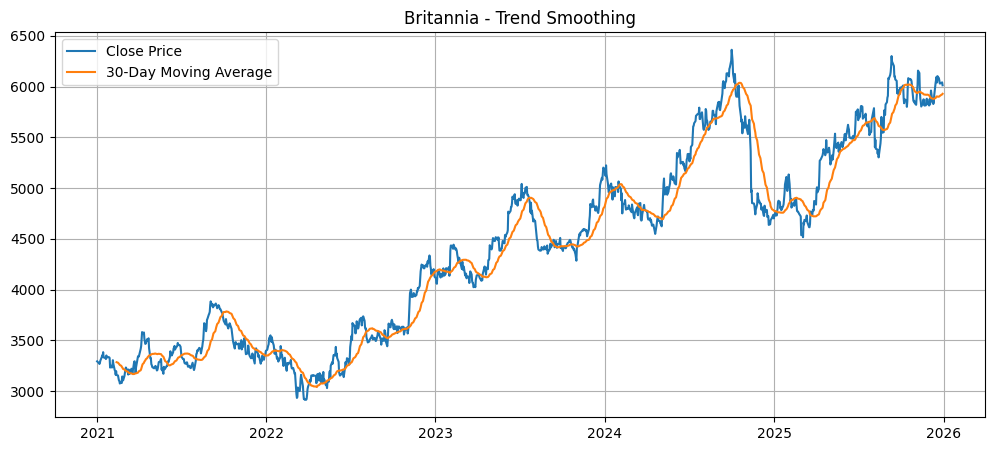

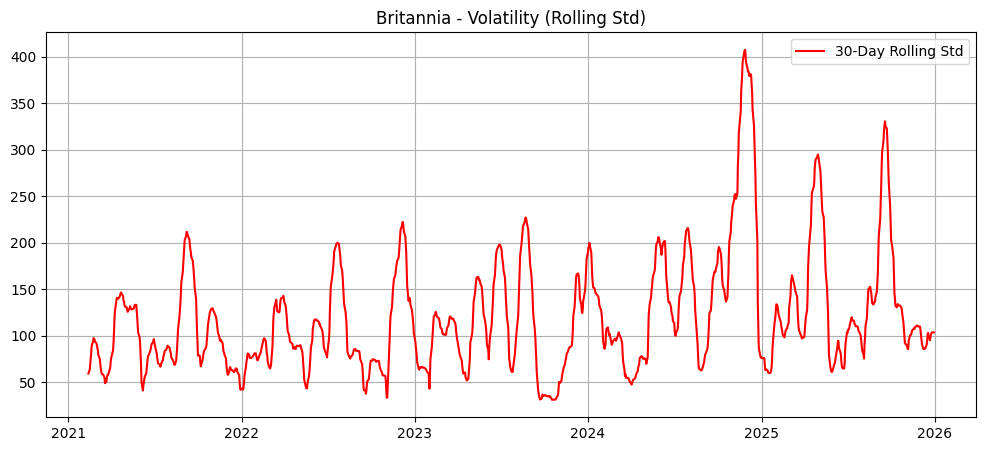

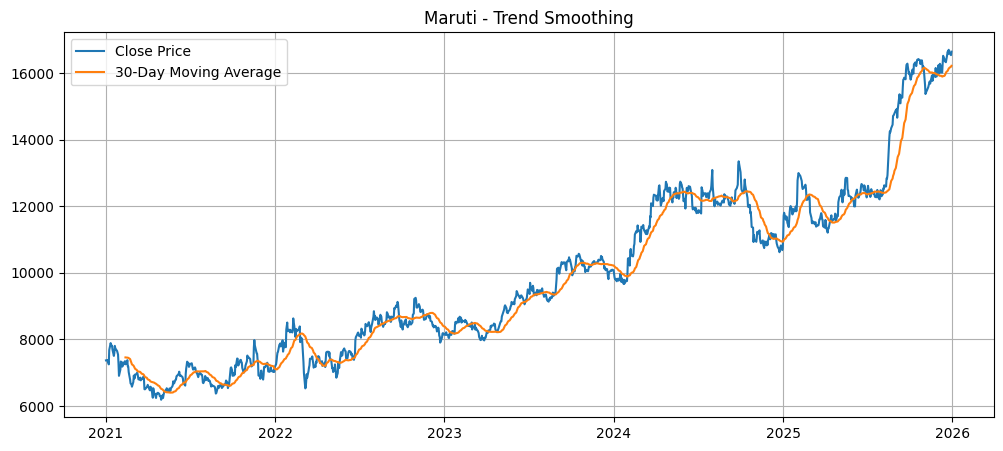

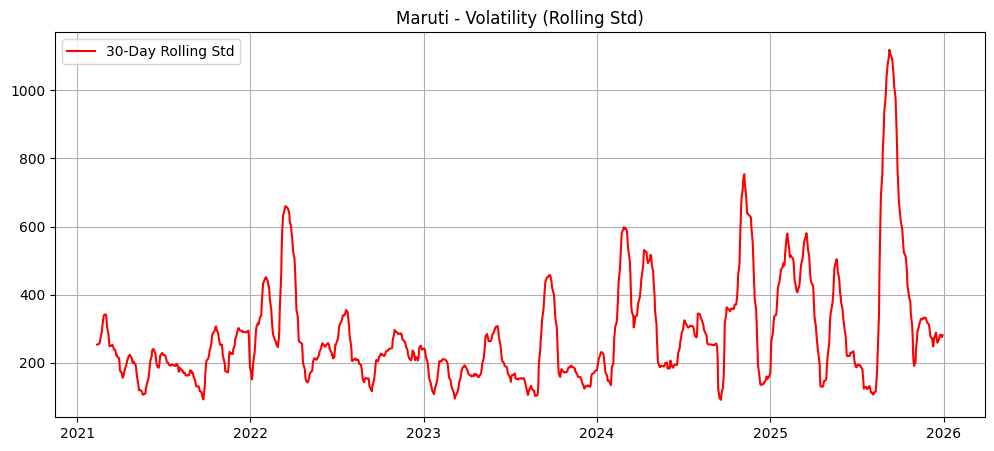

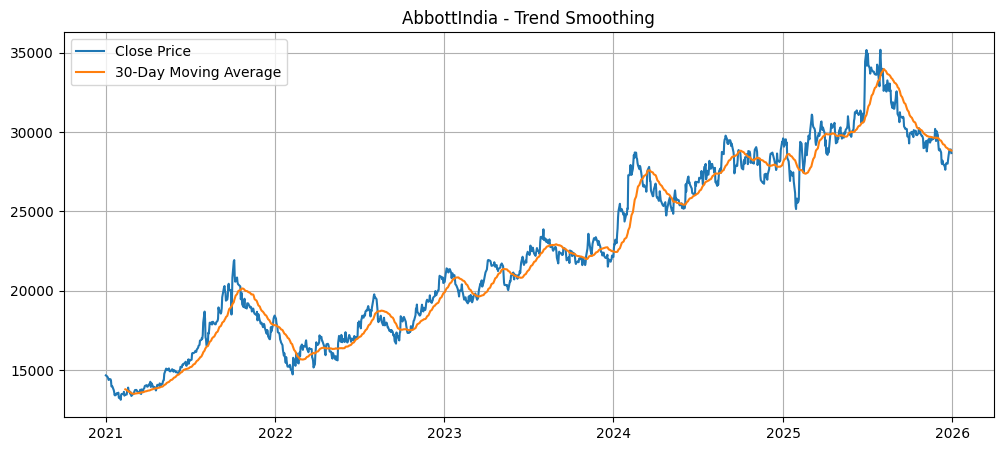

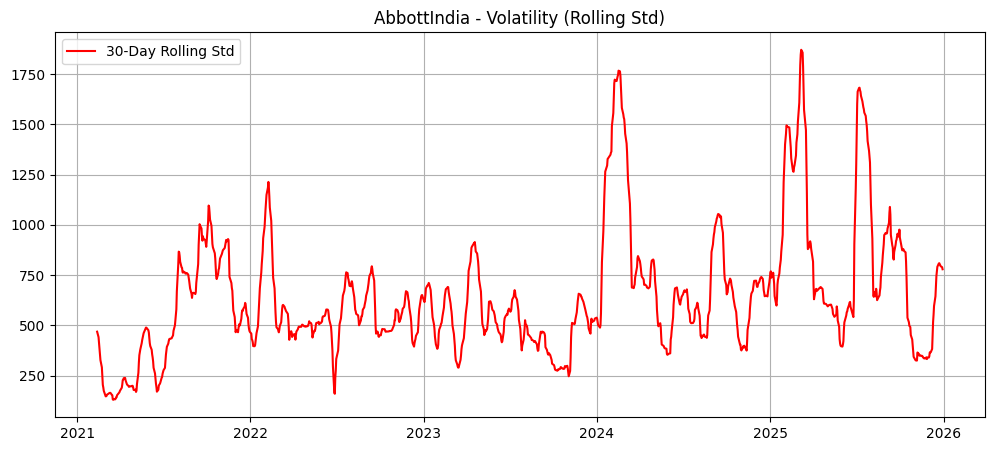

In [5]:
window = 30

for name, df in all_stock_data.items():
    df = df.copy()

    df["Rolling_Mean"] = df["Close"].rolling(window=window).mean()
    df["Rolling_Std"] = df["Close"].rolling(window=window).std()

    all_stock_data[name] = df

    # Plot Rolling Mean
    plt.figure(figsize=(12, 5))
    plt.plot(df["Close"], label="Close Price")
    plt.plot(df["Rolling_Mean"], label="30-Day Moving Average")
    plt.title(f"{name} - Trend Smoothing")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot Rolling Std
    plt.figure(figsize=(12, 5))
    plt.plot(df["Rolling_Std"], label="30-Day Rolling Std", color="red")
    plt.title(f"{name} - Volatility (Rolling Std)")
    plt.legend()
    plt.grid(True)
    plt.show()

In [6]:
for name, df in all_stock_data.items():
    df = df.copy()

    # Check missing values
    print(f"\n{name}")
    print("Missing values before:", df.isnull().sum().values)

    # Forward fill (safe for time series)
    df = df.ffill()

    # Backward fill (for initial missing values if any)
    df = df.bfill()

    # Store back
    all_stock_data[name] = df

    print("Missing values after:", df.isnull().sum().values)

print("\nData cleaning completed successfully")


Oracle
Missing values before: [ 0 29 29]
Missing values after: [0 0 0]

ICICI
Missing values before: [ 0 29 29]
Missing values after: [0 0 0]

Britannia
Missing values before: [ 0 29 29]
Missing values after: [0 0 0]

Maruti
Missing values before: [ 0 29 29]
Missing values after: [0 0 0]

AbbottIndia
Missing values before: [ 0 29 29]
Missing values after: [0 0 0]

Data cleaning completed successfully


In [7]:
for name, df in all_stock_data.items():
    print("\n" + "="*50)
    print(f"STOCK: {name}")
    print("="*50)

    print("\nShape:", df.shape)

    print("\nColumns:", df.columns.tolist())

    print("\nFirst 5 rows:")
    print(df.head())

    print("\nLast 5 rows:")
    print(df.tail())

    print("\nSummary Stats:")
    print(df.describe())

    print("\nMissing Values:")
    print(df.isnull().sum())


STOCK: Oracle

Shape: (1254, 3)

Columns: [('Close', 'ORCL'), ('Rolling_Mean', ''), ('Rolling_Std', '')]

First 5 rows:
Price           Close Rolling_Mean Rolling_Std
Ticker           ORCL                         
Date                                          
2021-01-04  59.099358    57.958364     0.88083
2021-01-05  58.366993    57.958364     0.88083
2021-01-06  58.227394    57.958364     0.88083
2021-01-07  58.692699    57.958364     0.88083
2021-01-08  58.981182    57.958364     0.88083

Last 5 rows:
Price            Close Rolling_Mean Rolling_Std
Ticker            ORCL                         
Date                                           
2025-12-23  194.146927   205.286471   14.993672
2025-12-24  196.283798   204.005675   14.002123
2025-12-26  196.780746   203.044912   13.446907
2025-12-29  194.186691   202.309764   13.302676
2025-12-30  196.005508   201.460317   12.841382

Summary Stats:
Price         Close Rolling_Mean  Rolling_Std
Ticker         ORCL                        

In [8]:
train_data = {}
test_data = {}

for name, df in all_stock_data.items():
    df = df.sort_index()

    split_date = "2025-07-01"

    train = df[df.index < split_date]
    test = df[df.index >= split_date]

    train_data[name] = train
    test_data[name] = test

    print("\n==============================")
    print(name)
    print("==============================")

    print("Train shape:", train.shape)
    print("Test shape:", test.shape)

    print("\nTrain range:", train.index.min(), "→", train.index.max())
    print("Test range:", test.index.min(), "→", test.index.max())


Oracle
Train shape: (1127, 3)
Test shape: (127, 3)

Train range: 2021-01-04 00:00:00 → 2025-06-30 00:00:00
Test range: 2025-07-01 00:00:00 → 2025-12-30 00:00:00

ICICI
Train shape: (1110, 3)
Test shape: (125, 3)

Train range: 2021-01-01 00:00:00 → 2025-06-30 00:00:00
Test range: 2025-07-01 00:00:00 → 2025-12-30 00:00:00

Britannia
Train shape: (1110, 3)
Test shape: (125, 3)

Train range: 2021-01-01 00:00:00 → 2025-06-30 00:00:00
Test range: 2025-07-01 00:00:00 → 2025-12-30 00:00:00

Maruti
Train shape: (1110, 3)
Test shape: (125, 3)

Train range: 2021-01-01 00:00:00 → 2025-06-30 00:00:00
Test range: 2025-07-01 00:00:00 → 2025-12-30 00:00:00

AbbottIndia
Train shape: (1110, 3)
Test shape: (125, 3)

Train range: 2021-01-01 00:00:00 → 2025-06-30 00:00:00
Test range: 2025-07-01 00:00:00 → 2025-12-30 00:00:00


In [9]:
scalers = {}
scaled_train = {}
scaled_test = {}

for name in train_data.keys():

    train_df = train_data[name]
    test_df = test_data[name]

    scaler = MinMaxScaler(feature_range=(0, 1))

    # Fit ONLY on training data
    train_scaled = scaler.fit_transform(train_df)

    # Transform test data using same scaler
    test_scaled = scaler.transform(test_df)

    scalers[name] = scaler
    scaled_train[name] = train_scaled
    scaled_test[name] = test_scaled

    print("\n==============================")
    print(name)
    print("Train scaled shape:", train_scaled.shape)
    print("Test scaled shape:", test_scaled.shape)


Oracle
Train scaled shape: (1127, 3)
Test scaled shape: (127, 3)

ICICI
Train scaled shape: (1110, 3)
Test scaled shape: (125, 3)

Britannia
Train scaled shape: (1110, 3)
Test scaled shape: (125, 3)

Maruti
Train scaled shape: (1110, 3)
Test scaled shape: (125, 3)

AbbottIndia
Train scaled shape: (1110, 3)
Test scaled shape: (125, 3)


In [10]:
def create_sequences(data, window_size=60):
    X, y = [], []

    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i, 0])  # Predict CLOSE price (column 0)

    return np.array(X), np.array(y)


X_train_data = {}
y_train_data = {}
X_test_data = {}
y_test_data = {}

window_size = 60

for name in scaled_train.keys():

    train = scaled_train[name]
    test = scaled_test[name]

    # Train sequences
    X_train, y_train = create_sequences(train, window_size)

    # Test sequences
    X_test, y_test = create_sequences(test, window_size)

    X_train_data[name] = X_train
    y_train_data[name] = y_train
    X_test_data[name] = X_test
    y_test_data[name] = y_test

    print("\n==============================")
    print(name)
    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)


Oracle
X_train: (1067, 60, 3)
y_train: (1067,)
X_test: (67, 60, 3)
y_test: (67,)

ICICI
X_train: (1050, 60, 3)
y_train: (1050,)
X_test: (65, 60, 3)
y_test: (65,)

Britannia
X_train: (1050, 60, 3)
y_train: (1050,)
X_test: (65, 60, 3)
y_test: (65,)

Maruti
X_train: (1050, 60, 3)
y_train: (1050,)
X_test: (65, 60, 3)
y_test: (65,)

AbbottIndia
X_train: (1050, 60, 3)
y_train: (1050,)
X_test: (65, 60, 3)
y_test: (65,)


In [11]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.6 MB/s eta 0:00:00


In [12]:
## LSTM

In [13]:
lstm_models = {}

for name in X_train_data.keys():

    model = Sequential()

    model.add(LSTM(64, return_sequences=True, input_shape=(60, 3)))
    model.add(LSTM(32))
    model.add(Dense(16, activation="relu"))
    model.add(Dense(1))

    model.compile(optimizer="adam", loss="mse")

    lstm_models[name] = model

print("LSTM models recreated successfully")

LSTM models recreated successfully


In [14]:
lstm_history = {}
lstm_predictions = {}

for name in X_train_data.keys():

    print("\n==============================")
    print(f"Training LSTM for {name}")
    print("==============================")

    model = lstm_models[name]

    X_train = X_train_data[name]
    y_train = y_train_data[name]

    X_test = X_test_data[name]
    y_test = y_test_data[name]

    history = model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=32,
        validation_data=(X_test, y_test),
        verbose=1
    )

    lstm_history[name] = history

    # Predictions
    preds = model.predict(X_test)
    lstm_predictions[name] = preds.flatten()


Training LSTM for Oracle
Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 15s 167ms/step - loss: 0.0274 - val_loss: 0.0469
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - loss: 0.0032 - val_loss: 0.0397
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.0023 - val_loss: 0.0365
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.0020 - val_loss: 0.0254
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0015 - val_loss: 0.0225
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0013 - val_loss: 0.0109
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0013 - val_loss: 0.0403
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0012 - val_loss: 0.0105
Epoch 9/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0011 - val_loss: 0.0267
Epoch 10/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 9.4765e-04 - val_loss: 0.0524
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step

Training LSTM for ICICI
Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - 

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step

Training LSTM for Maruti
Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - loss: 0.0361 - val_loss: 0.1083
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0035 - val_loss: 0.0870
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0029 - val_loss: 0.0571
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0027 - val_loss: 0.0640
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0025 - val_loss: 0.0396
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0022 - val_loss: 0.0401
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 0.0020 - val_loss: 0.0155
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0019 - val_loss: 0.0417
Epoch 9/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0022 - val_loss: 0.0185
Epoch 10/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0018 - val_loss: 0.0195
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step

Training LSTM for AbbottIndia
Epoch 1/10
33/

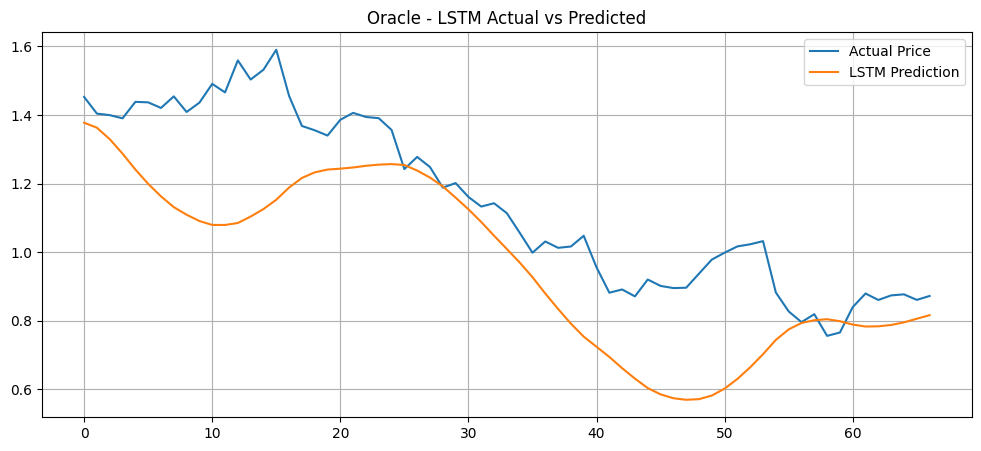

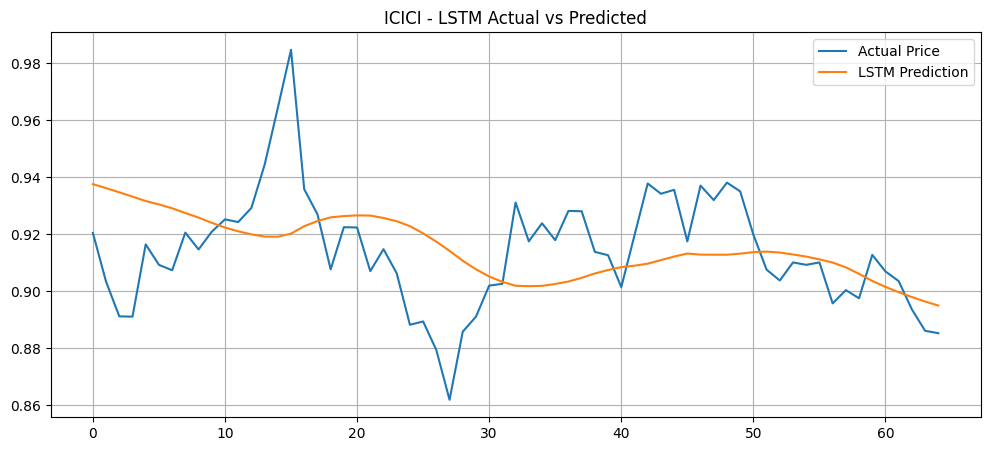

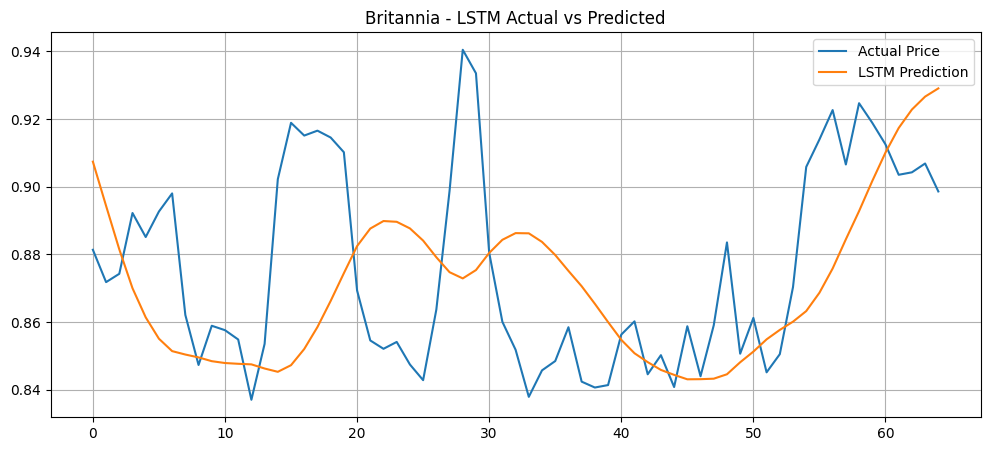

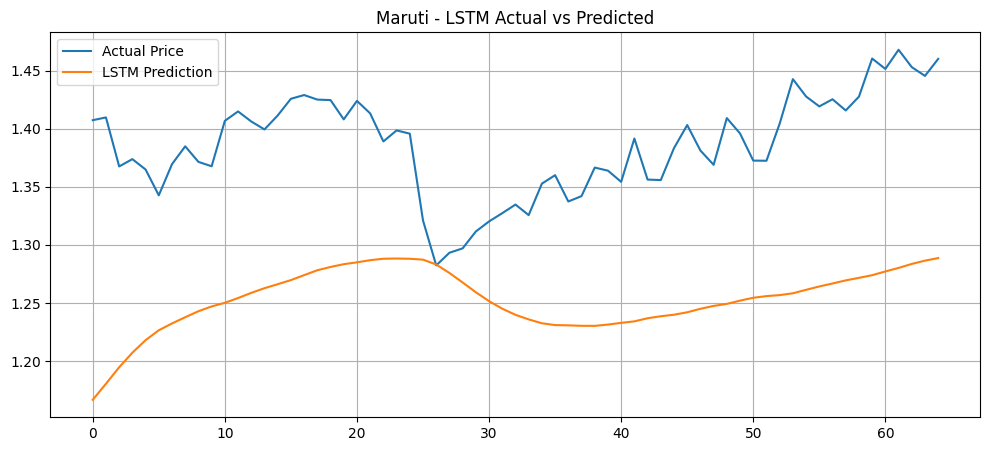

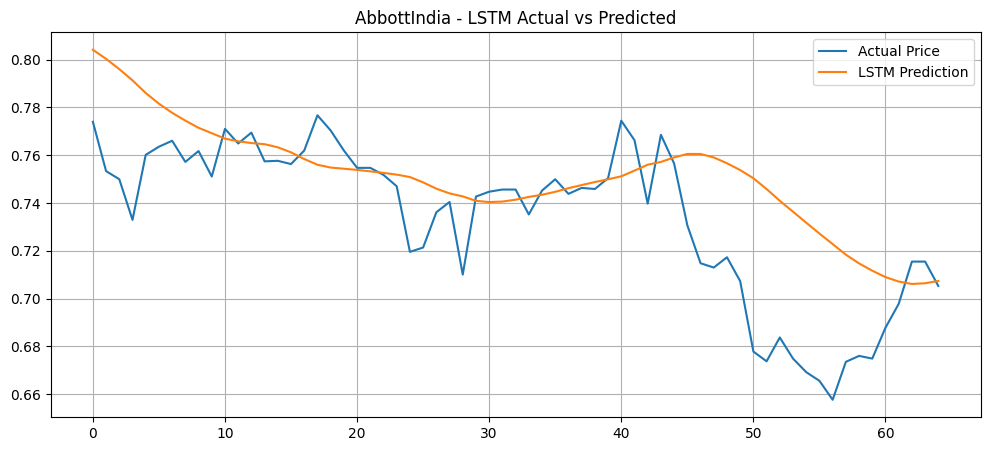

In [15]:
for name in X_test_data.keys():

    y_test = y_test_data[name]
    preds = lstm_predictions[name]

    plt.figure(figsize=(12,5))

    plt.plot(y_test, label="Actual Price")
    plt.plot(preds, label="LSTM Prediction")

    plt.title(f"{name} - LSTM Actual vs Predicted")
    plt.legend()
    plt.grid(True)
    plt.show()

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

lstm_metrics = {}

for name in y_test_data.keys():

    y_test = y_test_data[name]
    preds = lstm_predictions[name]

    # reshape safety
    y_test = np.array(y_test).reshape(-1)
    preds = np.array(preds).reshape(-1)

    # metrics
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)

    lstm_metrics[name] = {"RMSE": rmse, "MAE": mae}

    print("\n==============================")
    print(name)
    print("RMSE:", rmse)
    print("MAE :", mae)


Oracle
RMSE: 0.22890080243348598
MAE : 0.18504761587348295

ICICI
RMSE: 0.02149543193374321
MAE : 0.01677683790601678

Britannia
RMSE: 0.031058797557089058
MAE : 0.02515733351137827

Maruti
RMSE: 0.13970559948233602
MAE : 0.13296798717656166

AbbottIndia
RMSE: 0.030227765995587057
MAE : 0.021591807472910625


GRU

In [17]:
gru_models = {}

for name in X_train_data.keys():

    model = Sequential()

    model.add(GRU(64, return_sequences=True, input_shape=(60, 3)))
    model.add(GRU(32))

    model.add(Dense(16, activation="relu"))
    model.add(Dense(1))

    model.compile(optimizer="adam", loss="mse")

    gru_models[name] = model

    print("\n==============================")
    print(f"GRU Model Built for {name}")
    model.summary()


GRU Model Built for Oracle


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 64)         │        13,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,201 (90.63 KB)

 Trainable params: 23,201 (90.63 KB)

...

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_8 (GRU)                     │ (None, 60, 64)         │        13,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_9 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,201 (90.63 KB)

 Trainable params: 23,201 (90.63 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
gru_history = {}
gru_predictions = {}

for name in X_train_data.keys():

    print("\n==============================")
    print(f"Training GRU for {name}")
    print("==============================")

    model = gru_models[name]

    X_train = X_train_data[name]
    y_train = y_train_data[name]

    X_test = X_test_data[name]
    y_test = y_test_data[name]

    history = model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=32,
        validation_data=(X_test, y_test),
        verbose=1
    )

    gru_history[name] = history

    preds = model.predict(X_test)
    gru_predictions[name] = preds.flatten()


Training GRU for Oracle
Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 17s 202ms/step - loss: 0.0277 - val_loss: 0.0257
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0022 - val_loss: 0.0230
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0013 - val_loss: 0.0123
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 9.8933e-04 - val_loss: 0.0079
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 6.7447e-04 - val_loss: 0.0070
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - loss: 6.0114e-04 - val_loss: 0.0099
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 5.4584e-04 - val_loss: 0.0066
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 5.7788e-04 - val_loss: 0.0112
Epoch 9/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 4.6444e-04 - val_loss: 0.0068
Epoch 10/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 4.7815e-04 - val_loss: 0.0059
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 305ms/step

Training GRU for ICICI
Epoch 1/10
33/33 ━━━━━━━━━━━━━━

In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

gru_metrics = {}

for name in y_test_data.keys():

    y_test = np.array(y_test_data[name]).reshape(-1)
    preds = np.array(gru_predictions[name]).reshape(-1)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)

    gru_metrics[name] = {"RMSE": rmse, "MAE": mae}

    print("\n==============================")
    print(name)
    print("RMSE:", rmse)
    print("MAE :", mae)


Oracle
RMSE: 0.07666046893096626
MAE : 0.06324318520279701

ICICI
RMSE: 0.020364596433526398
MAE : 0.01642731859489221

Britannia
RMSE: 0.024672276225962575
MAE : 0.01826471324861673

Maruti
RMSE: 0.06414886603804908
MAE : 0.06083860303260362

AbbottIndia
RMSE: 0.015667687688847267
MAE : 0.01214851265598301


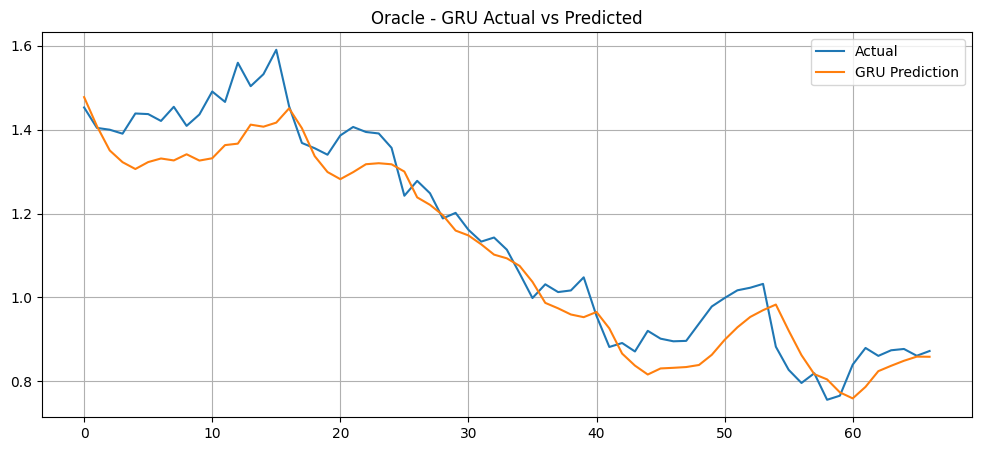

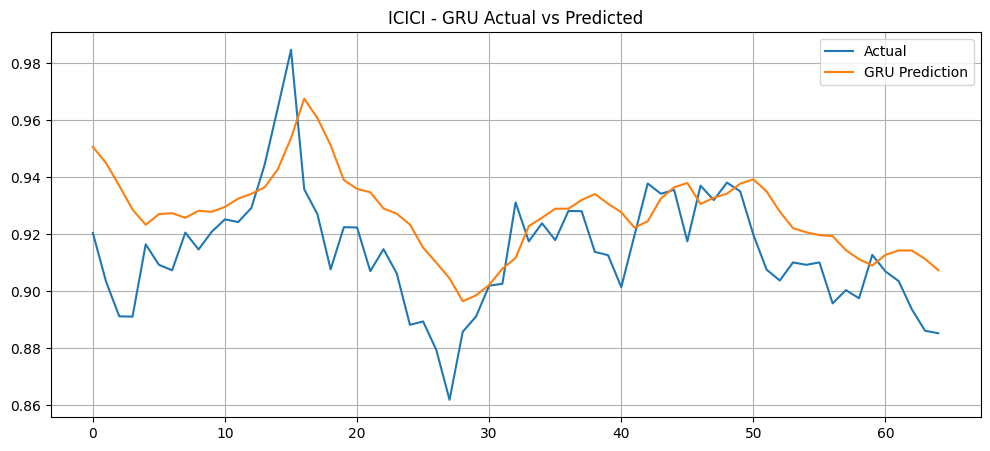

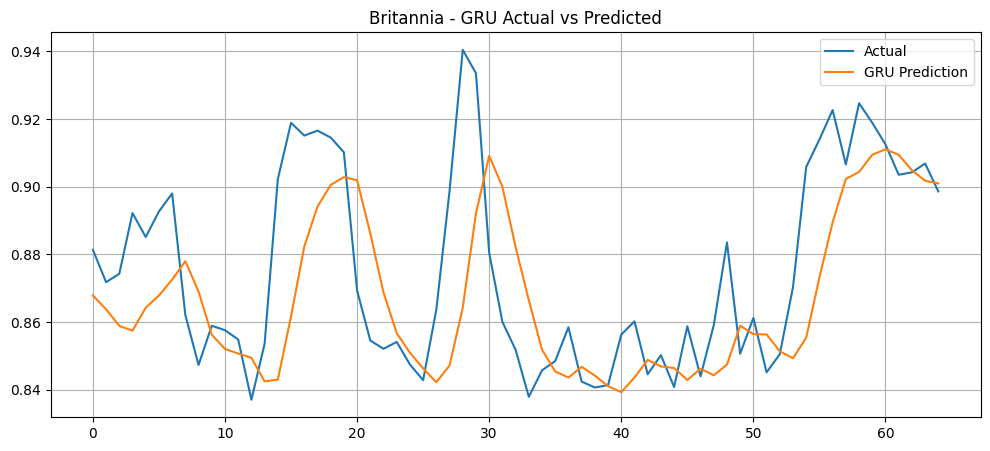

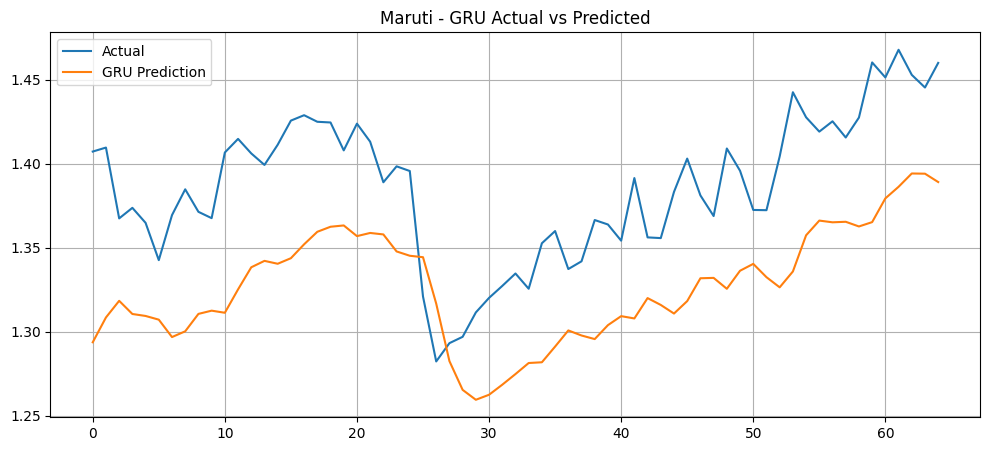

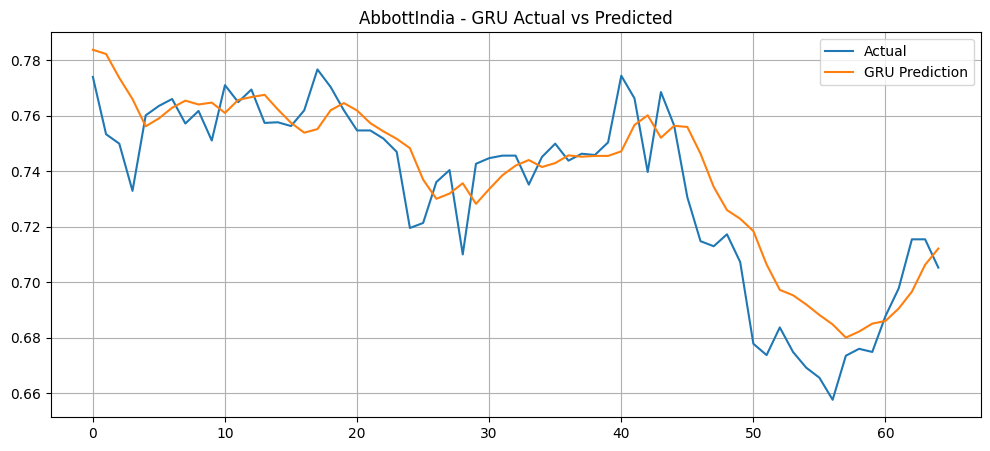

In [20]:
for name in X_test_data.keys():

    y_test = y_test_data[name]
    preds = gru_predictions[name]

    plt.figure(figsize=(12,5))

    plt.plot(y_test, label="Actual")
    plt.plot(preds, label="GRU Prediction")

    plt.title(f"{name} - GRU Actual vs Predicted")
    plt.legend()
    plt.grid(True)
    plt.show()

ARIMA

In [39]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

arima_predictions = {}
arima_metrics = {}

for name in all_stock_data.keys():

    # Scaled data use karo (same as LSTM/GRU)
    train_scaled = scaled_train[name][:, 0]  # sirf Close column (column 0)
    test_scaled  = scaled_test[name][:, 0]

    if len(test_scaled) == 0:
        print(f"Skipping {name}: no test data")
        continue

    try:
        model = ARIMA(train_scaled, order=(5, 1, 0))
        model_fit = model.fit()

        # Forecast scaled values
        pred_scaled = model_fit.forecast(steps=len(test_scaled))

        # Inverse transform karo real prices mein
        scaler = scalers[name]

        dummy_pred = np.zeros((len(pred_scaled), 3))
        dummy_pred[:, 0] = pred_scaled
        pred_real = scaler.inverse_transform(dummy_pred)[:, 0]

        dummy_actual = np.zeros((len(test_scaled), 3))
        dummy_actual[:, 0] = test_scaled
        actual_real = scaler.inverse_transform(dummy_actual)[:, 0]

        mse  = mean_squared_error(actual_real, pred_real)
        rmse = np.sqrt(mse)
        mae  = mean_absolute_error(actual_real, pred_real)

        arima_predictions[name] = pred_real   # real prices store karo
        arima_metrics[name] = {"MSE": mse, "RMSE": rmse, "MAE": mae}

        print(f"{name}  RMSE: {rmse:.4f}  MAE: {mae:.4f}")

    except Exception as e:
        print(f"ARIMA failed for {name}: {e}")

print("\nARIMA metrics:", arima_metrics)

Oracle  RMSE: 45.4820  MAE: 36.1605
ICICI  RMSE: 52.4223  MAE: 44.7398
Britannia  RMSE: 212.6368  MAE: 169.9593
Maruti  RMSE: 3072.1030  MAE: 2639.8053
AbbottIndia  RMSE: 4196.3804  MAE: 3697.0905

ARIMA metrics: {'Oracle': {'MSE': 2068.6130303085383, 'RMSE': np.float64(45.482007764703376), 'MAE': 36.16046496631567}, 'ICICI': {'MSE': 2748.096505571085, 'RMSE': np.float64(52.42229015954077), 'MAE': 44.73983672329056}, 'Britannia': {'MSE': 45214.42578584543, 'RMSE': np.float64(212.63684014263717), 'MAE': 169.9593283124271}, 'Maruti': {'MSE': 9437816.831525719, 'RMSE': np.float64(3072.102998196141), 'MAE': 2639.805269696017}, 'AbbottIndia': {'MSE': 17609608.30235893, 'RMSE': np.float64(4196.380381037798), 'MAE': 3697.0905195528517}}


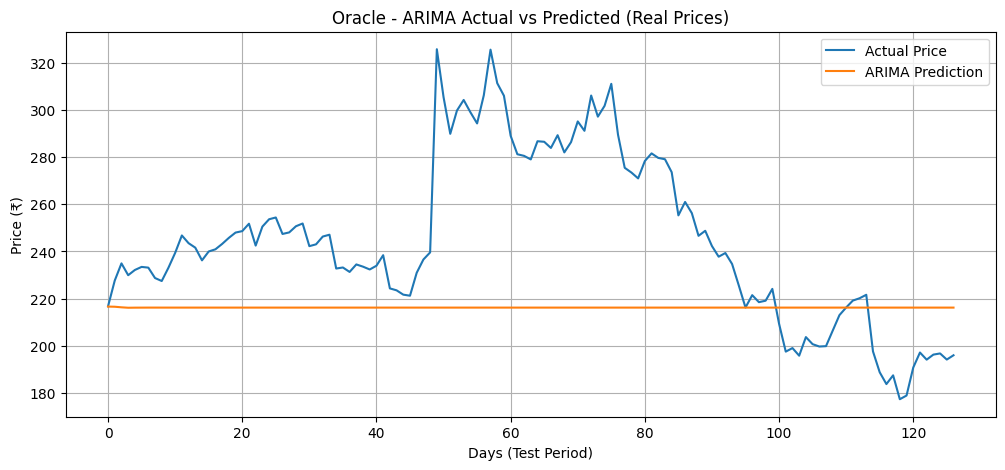

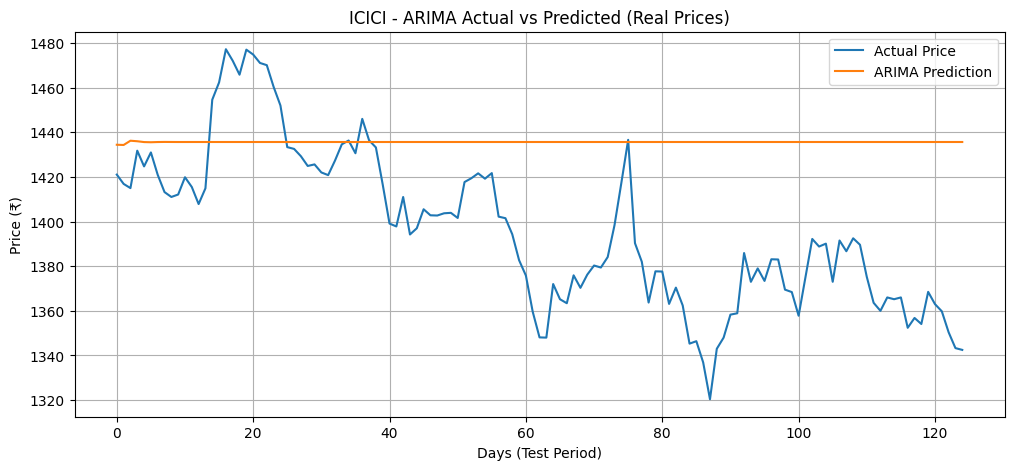

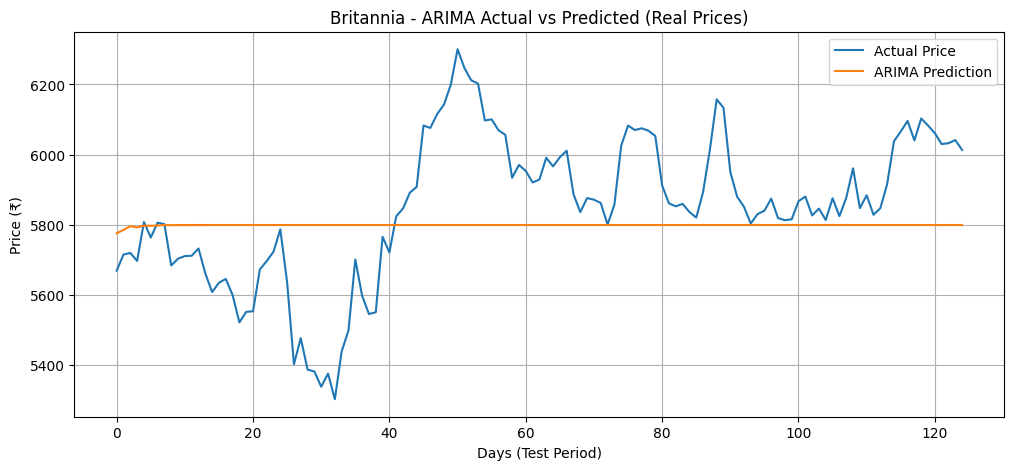

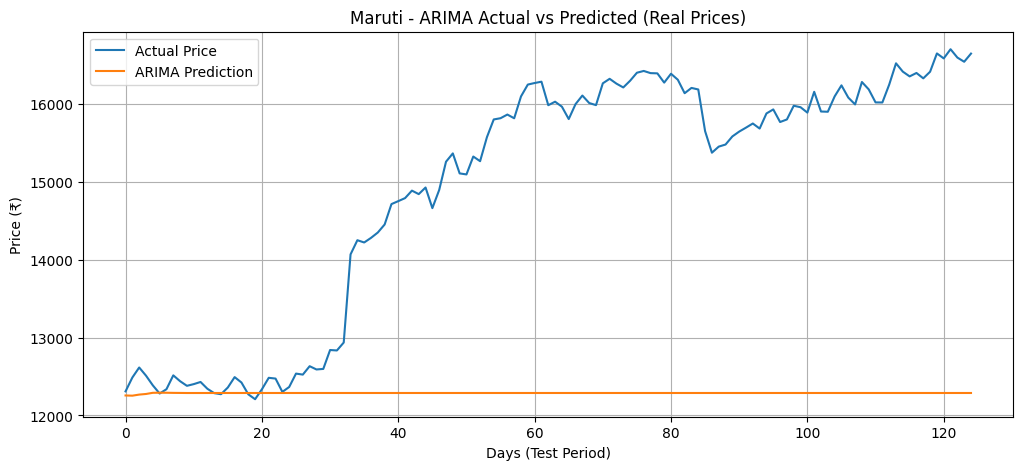

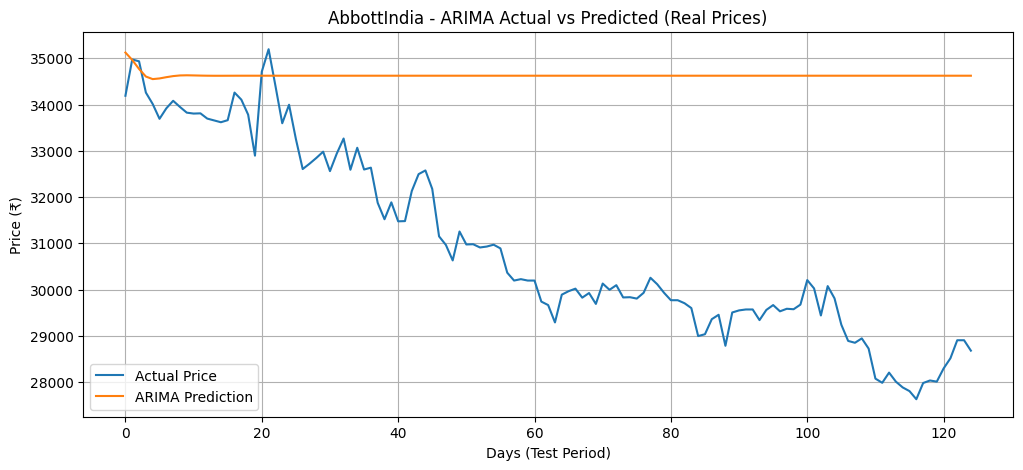

In [40]:
import matplotlib.pyplot as plt
import numpy as np

for name in arima_predictions.keys():

    # arima_predictions ab real prices mein hain
    pred_real   = arima_predictions[name]
    actual_real = test_data[name]["Close"].squeeze().values.astype(float)

    min_len = min(len(actual_real), len(pred_real))
    actual_real = actual_real[:min_len]
    pred_real   = pred_real[:min_len]

    plt.figure(figsize=(12, 5))
    plt.plot(actual_real, label="Actual Price")
    plt.plot(pred_real,   label="ARIMA Prediction")
    plt.title(f"{name} - ARIMA Actual vs Predicted (Real Prices)")
    plt.xlabel("Days (Test Period)")
    plt.ylabel("Price (₹)")
    plt.legend()
    plt.grid(True)
    plt.show()

In [41]:
comparison = []

for name in lstm_metrics.keys():

    comparison.append([
        name,
        arima_metrics[name]["RMSE"] if name in arima_metrics else None,
        lstm_metrics[name]["RMSE"],
        gru_metrics[name]["RMSE"]
    ])

df_compare = pd.DataFrame(
    comparison,
    columns=["Stock", "ARIMA_RMSE", "LSTM_RMSE", "GRU_RMSE"]
)

df_compare

,Stock,ARIMA_RMSE,LSTM_RMSE,GRU_RMSE
0,Oracle,45.482008,0.228901,0.076660
1,ICICI,52.422290,0.021495,0.020365
2,Britannia,212.636840,0.031059,0.024672
3,Maruti,3072.102998,0.139706,0.064149
4,AbbottIndia,4196.380381,0.030228,0.015668


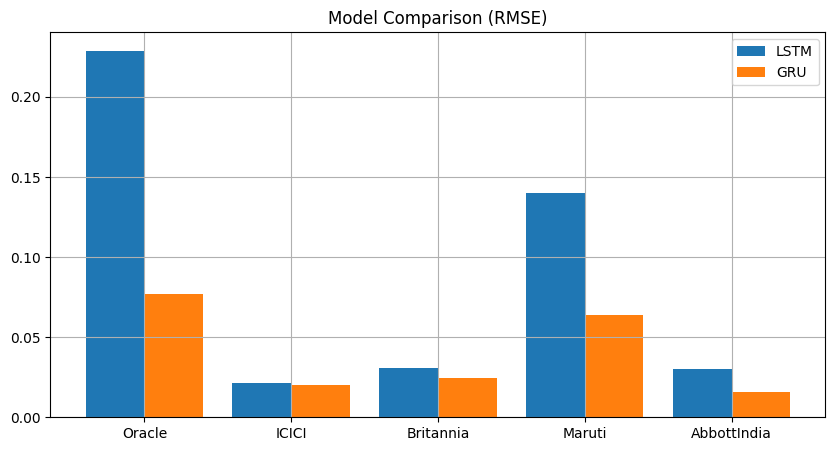

In [42]:
plt.figure(figsize=(10,5))

x = np.arange(len(df_compare["Stock"]))

plt.bar(x - 0.2, df_compare["LSTM_RMSE"], width=0.4, label="LSTM")
plt.bar(x + 0.2, df_compare["GRU_RMSE"], width=0.4, label="GRU")

plt.xticks(x, df_compare["Stock"])
plt.title("Model Comparison (RMSE)")
plt.legend()
plt.grid(True)
plt.show()

In [43]:
def predict_future(model, last_sequence, days=5):

    future_preds = []

    current_seq = last_sequence.copy()

    for _ in range(days):

        pred = model.predict(current_seq.reshape(1, 60, 3))[0][0]
        future_preds.append(pred)

        # shift sequence
        new_row = np.array([pred, pred, pred])  # simplified approximation

        current_seq = np.vstack([current_seq[1:], new_row])

    return future_preds

In [44]:
future_predictions = {}

for name in X_test_data.keys():

    model = lstm_models[name]

    last_seq = X_test_data[name][-1]

    preds = predict_future(model, last_seq, days=5)

    future_predictions[name] = preds

    print("\n==============================")
    print(name)
    print("Next 5 day predictions:", preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

Oracle
Next 5 day predictions: [np.float32(0.8164866), np.float32(0.8288972), np.float32(0.84023064), np.float32(0.85068166), np.float32(0.8601305)]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

ICICI
Next 5 day predictions: [np.float32(0.89498216), np.float32(0.9021031), np.float32(0.9091218), np.float32(0.9157046), np.float32(0.9216086)]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

Britannia
Next 5 day predictions: [np.float32(0.9290837), np.float32(0.9276203), np.float32(0.9227294), np.float32(0.9149423), np.f

In [45]:
import yfinance as yf
live_prices = {}
for name, ticker in stocks.items():
    data = yf.Ticker(ticker).history(period="1d")
    live_price = data["Close"].values[-1]
    live_prices[name] = live_price
    print(name, "Live Price:", live_price)

Oracle Live Price: 157.52999877929688
ICICI Live Price: 1373.5999755859375
Britannia Live Price: 5262.5
Maruti Live Price: 13248.0
AbbottIndia Live Price: 25595.0


In [46]:
gru_predictions_real = {}
for name in gru_predictions.keys():

    preds = np.array(gru_predictions[name]).reshape(-1, 1)

    scaler = scalers[name]

    # IMPORTANT: rebuild full 3-feature dummy
    dummy = np.zeros((len(preds), 3))
    dummy[:, 0] = preds[:, 0]

    inv = scaler.inverse_transform(dummy)

    gru_predictions_real[name] = inv[:, 0]

print("Inverse transform complete")

Inverse transform complete


In [47]:
comparison_table = []

for name in stocks.keys():

    predicted = gru_predictions_real[name][-1]
    actual = live_prices[name]

    error_pct = abs(predicted - actual) / actual * 100

    comparison_table.append([name, predicted, actual, error_pct])

df_final = pd.DataFrame(
    comparison_table,
    columns=["Stock", "Predicted", "Live Price", "Error %"]
)

df_final

,Stock,Predicted,Live Price,Error %
0,Oracle,193.798542,157.529999,23.023261
1,ICICI,1363.436457,1373.599976,0.739918
2,Britannia,6021.170077,5262.500000,14.416534
3,Maruti,16138.971950,13248.000000,21.821950
4,AbbottIndia,28831.741778,25595.000000,12.645992


In [48]:
lstm_predictions_real = {}

for name in lstm_predictions.keys():

    preds = np.array(lstm_predictions[name]).reshape(-1, 1)

    scaler = scalers[name]

    dummy = np.zeros((len(preds), 3))
    dummy[:, 0] = preds[:, 0]

    inv = scaler.inverse_transform(dummy)

    lstm_predictions_real[name] = inv[:, 0]

In [52]:
comparison_table = []

for name in stocks.keys():

    predicted = lstm_predictions_real[name][-1]
    actual = live_prices[name]

    error_pct = abs(predicted - actual) / actual * 100

    comparison_table.append([name, predicted, actual, error_pct])

df_final = pd.DataFrame(
    comparison_table,
    columns=["Stock", "Predicted", "Live Price", "Error %"]
)
df_final

,Stock,Predicted,Live Price,Error %
0,Oracle,187.043432,157.529999,18.735120
1,ICICI,1351.678710,1373.599976,1.595899
2,Britannia,6118.109707,5262.500000,16.258617
3,Maruti,15419.161314,13248.000000,16.388597
4,AbbottIndia,28726.477566,25595.000000,12.234724


In [49]:
y_test_real = {}

for name in y_test_data.keys():

    y = np.array(y_test_data[name]).reshape(-1, 1)

    scaler = scalers[name]

    dummy = np.zeros((len(y), 3))
    dummy[:, 0] = y[:, 0]

    inv = scaler.inverse_transform(dummy)

    y_test_real[name] = inv[:, 0]

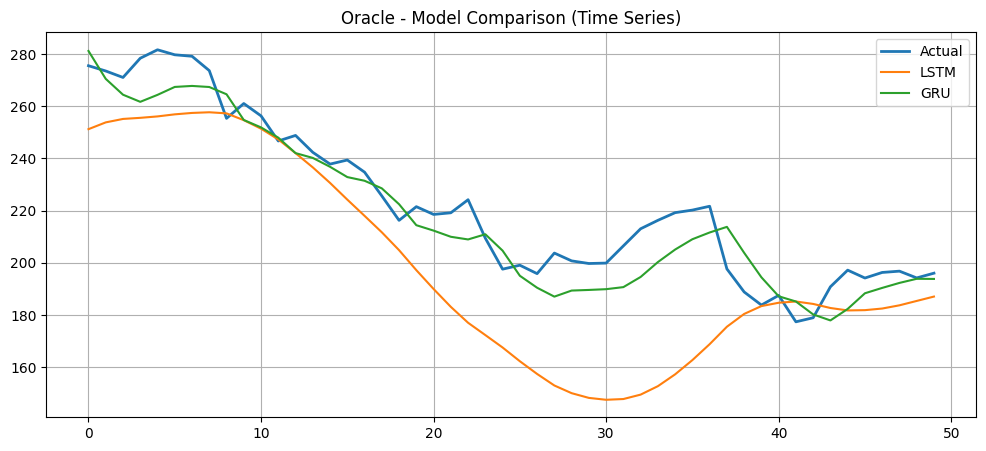

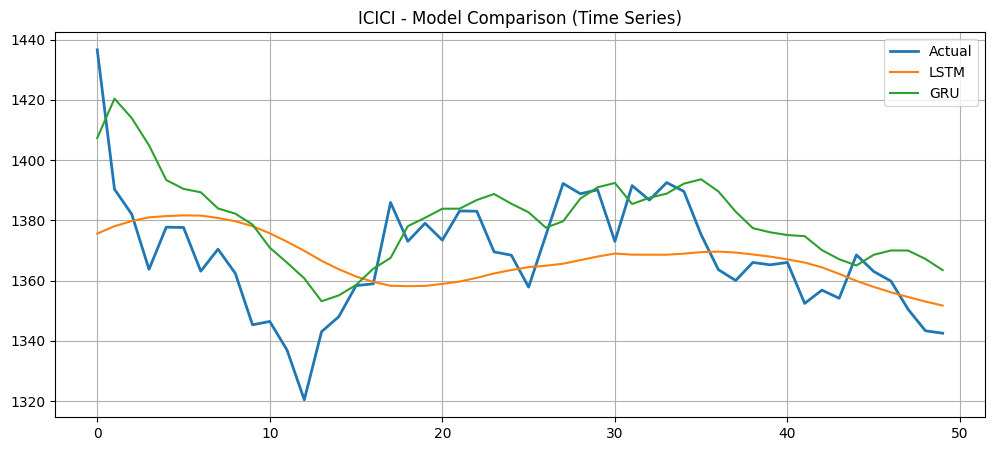

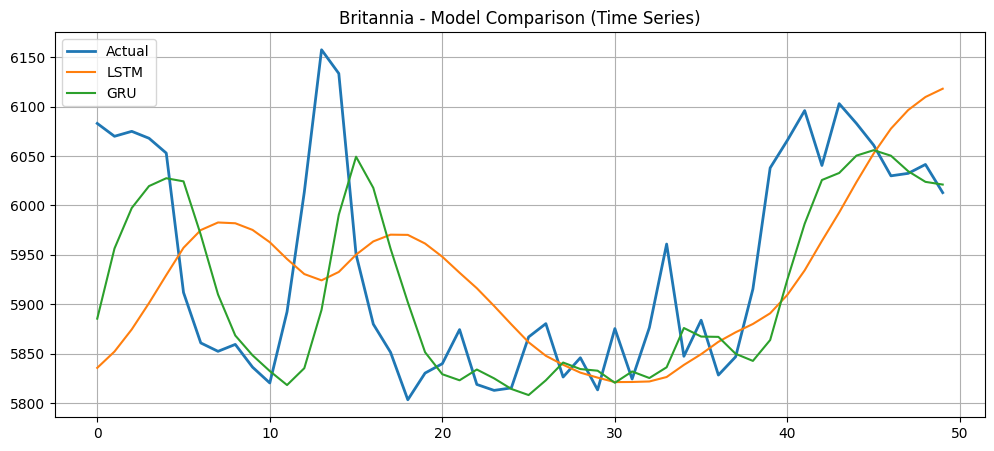

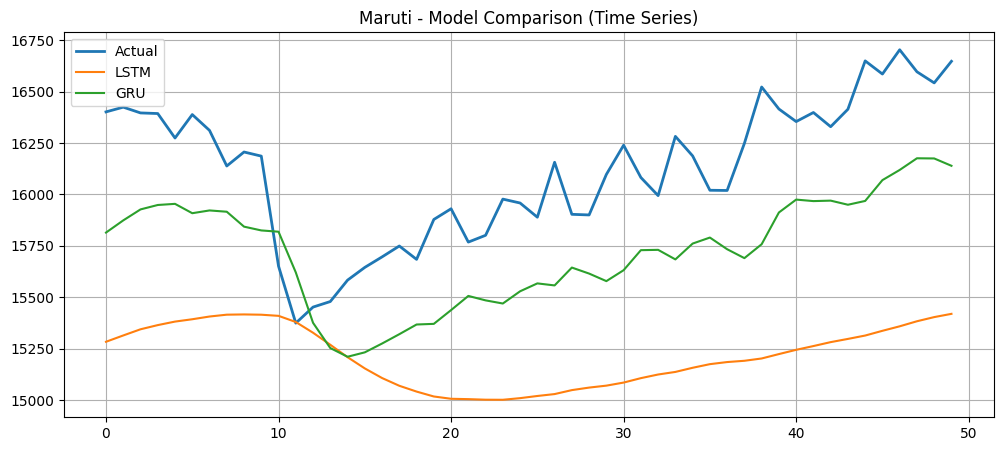

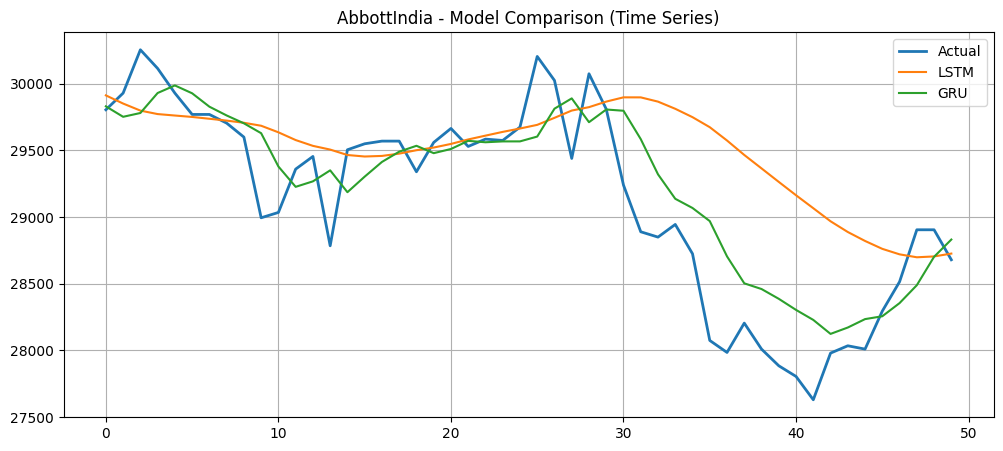

In [50]:
for name in stocks.keys():

    plt.figure(figsize=(12,5))

    actual_series = y_test_real[name][-50:]   # last 50 points
    lstm_series = lstm_predictions_real[name][-50:]
    gru_series = gru_predictions_real[name][-50:]

    x = np.arange(len(actual_series))

    plt.plot(x, actual_series, label="Actual", linewidth=2)
    plt.plot(x, lstm_series, label="LSTM")
    plt.plot(x, gru_series, label="GRU")

    plt.title(f"{name} - Model Comparison (Time Series)")
    plt.legend()
    plt.grid(True)
    plt.show()


Running Ridge Regression for Oracle
✔ Oracle Completed -> RMSE: 16.3189 | MAE: 11.5030


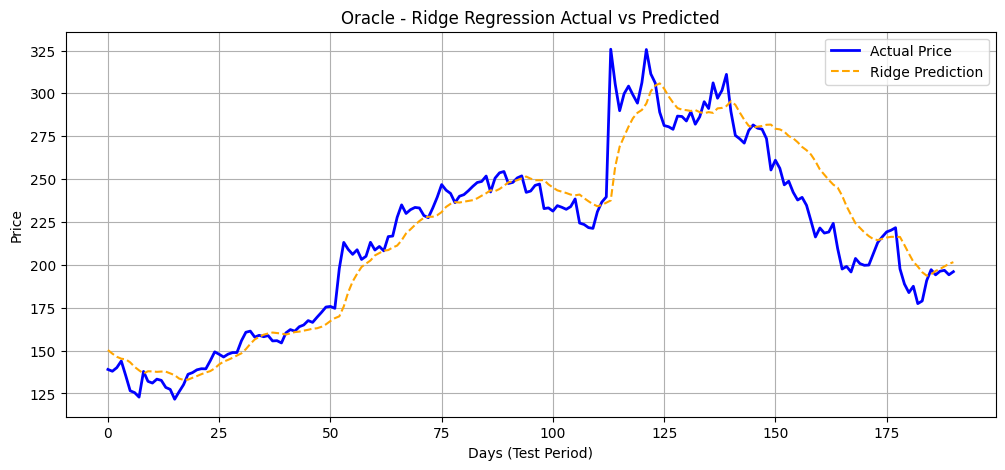


Running Ridge Regression for ICICI
✔ ICICI Completed -> RMSE: 19.4423 | MAE: 15.2127


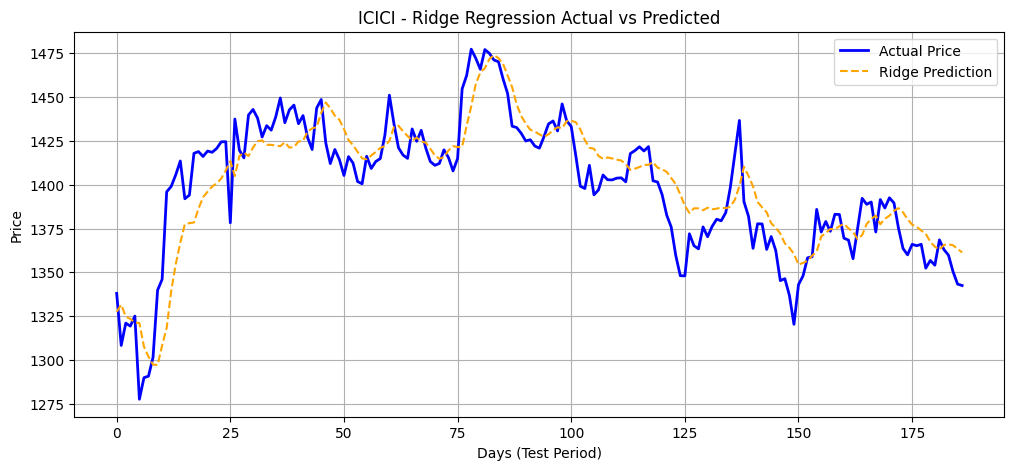


Running Ridge Regression for Britannia
✔ Britannia Completed -> RMSE: 89.5548 | MAE: 69.6314


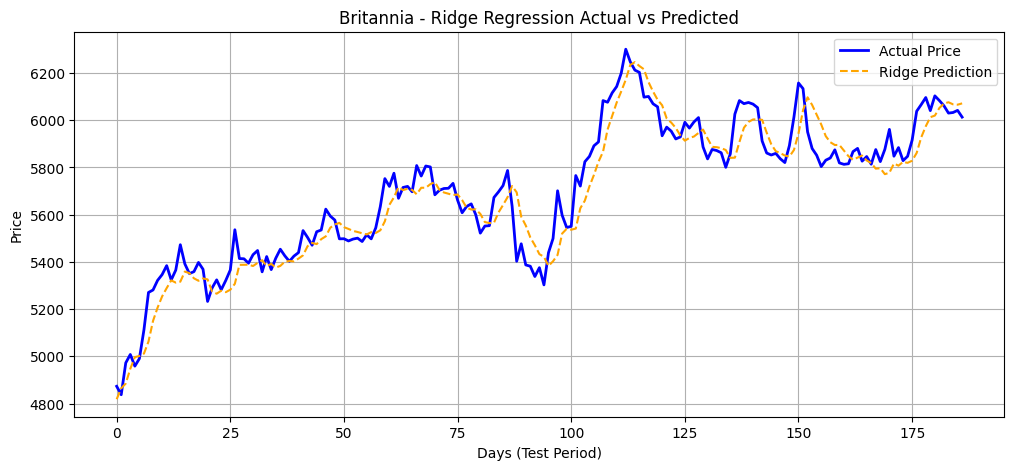


Running Ridge Regression for Maruti
✔ Maruti Completed -> RMSE: 286.2576 | MAE: 213.9794


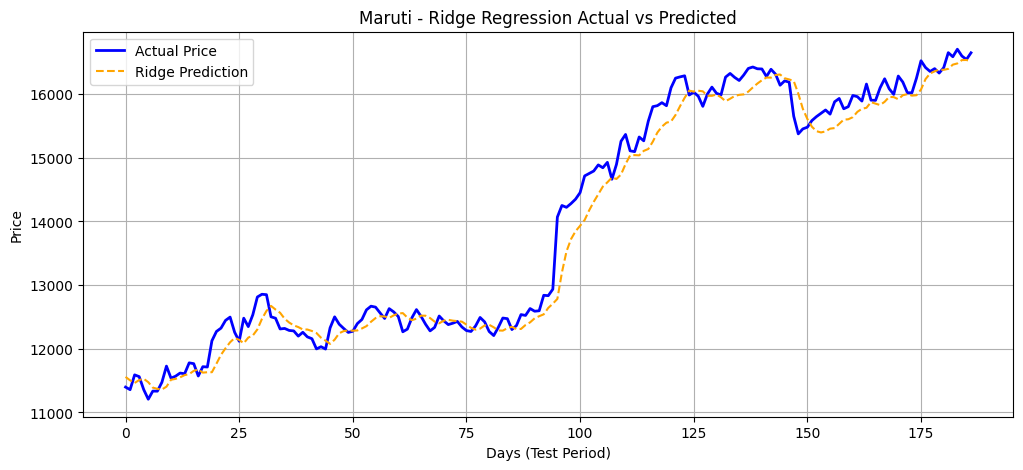


Running Ridge Regression for AbbottIndia
✔ AbbottIndia Completed -> RMSE: 593.4750 | MAE: 433.5739


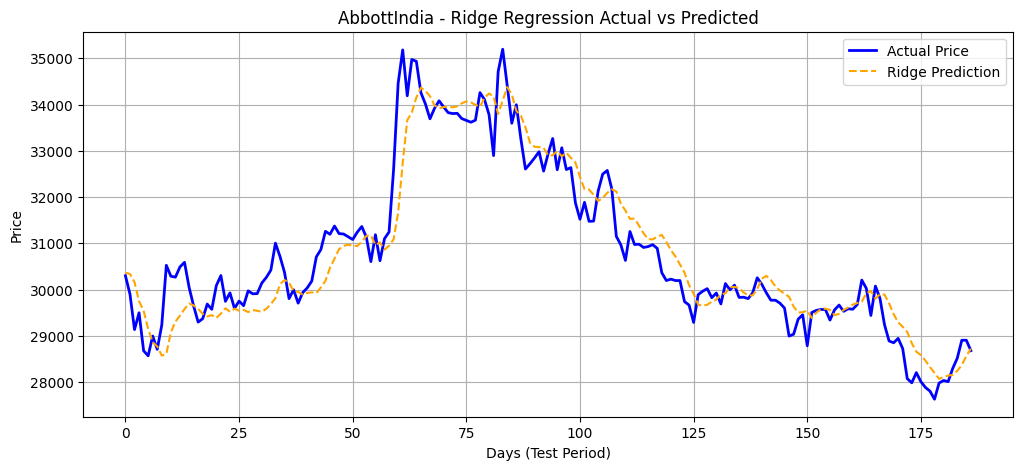

In [53]:
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Sabhi stocks ke liye predictions aur actual prices store karne ke dicts
ridge_predictions_real = {}
y_test_real_prices = {}
ridge_metrics = {}

# Constants aapki configuration ke hisab se
WINDOW_SIZE = 60
TRAIN_SPLIT = 0.8  # Agar aap 80% split use kar rahe hain streamlit ke tarah

for name in all_stock_data.keys():
    print(f"\n==============================")
    print(f"Running Ridge Regression for {name}")
    print(f"==============================")

    # 1. Feature Engineering (Jaise aapke Streamlit app mein hai)
    df_feat = all_stock_data[name].copy()
    df_feat["MA_30"] = df_feat["Close"].rolling(window=30).mean()
    df_feat["Volatility"] = df_feat["Close"].rolling(window=30).std()
    df_feat = df_feat.ffill().bfill()

    data = df_feat[["Close", "MA_30", "Volatility"]].values

    # 2. Scaling
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled = scaler.fit_transform(data)

    # 3. Train-Test Split
    split = int(len(scaled) * TRAIN_SPLIT)
    train, test = scaled[:split], scaled[split:]

    # 4. Creating Sequences (LSTM-style matrix)
    X_train, y_train = create_sequences(train, WINDOW_SIZE)
    X_test, y_test = create_sequences(test, WINDOW_SIZE)

    # 5. Flattening 3D to 2D for Ridge Regressor
    X_tr = X_train.reshape(len(X_train), -1)
    X_te = X_test.reshape(len(X_test), -1)

    # 6. Model Training
    model = Ridge(alpha=1.0)
    model.fit(X_tr, y_train)

    # 7. Predictions
    preds_scaled = model.predict(X_te)

    # 8. Inverse Transform using your dummy matrix strategy
    dummy_pred = np.zeros((len(preds_scaled), 3))
    dummy_pred[:, 0] = preds_scaled
    pred_prices = scaler.inverse_transform(dummy_pred)[:, 0]

    dummy_actual = np.zeros((len(y_test), 3))
    dummy_actual[:, 0] = y_test
    actual_prices = scaler.inverse_transform(dummy_actual)[:, 0]

    # Storing results for comparison
    ridge_predictions_real[name] = pred_prices
    y_test_real_prices[name] = actual_prices

    # Metrics Calculation
    rmse = np.sqrt(mean_squared_error(actual_prices, pred_prices))
    mae = mean_absolute_error(actual_prices, pred_prices)
    print(f"✔ {name} Completed -> RMSE: {rmse:.4f} | MAE: {mae:.4f}")

    # 9. Graph Generation (Bilkul pehle jaisa)
    plt.figure(figsize=(12, 5))
    plt.plot(actual_prices, label="Actual Price", linewidth=2, color='blue')
    plt.plot(pred_prices, label="Ridge Prediction", linewidth=1.5, color='orange', linestyle='--')

    plt.title(f"{name} - Ridge Regression Actual vs Predicted")
    plt.xlabel("Days (Test Period)")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True)
    plt.show()

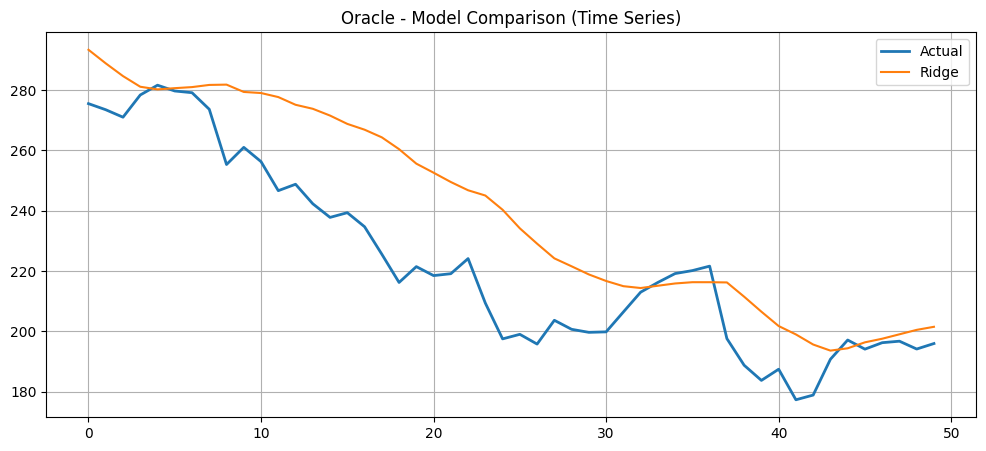

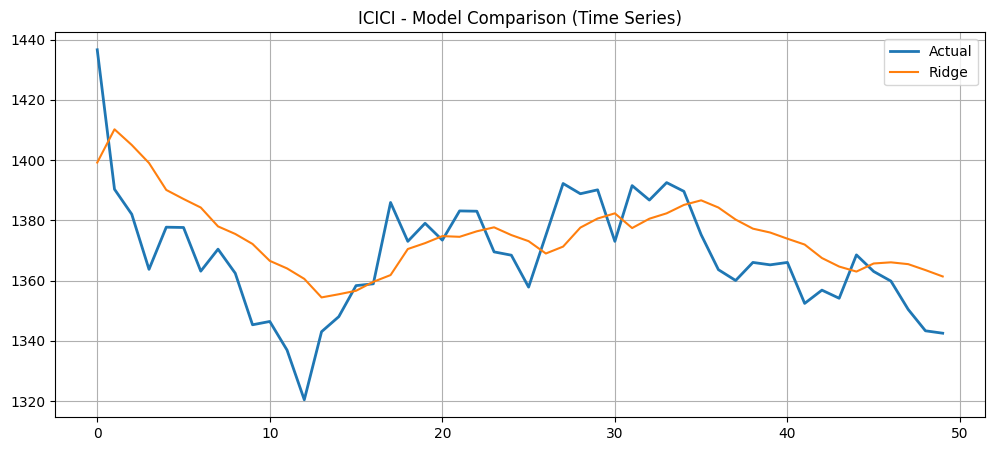

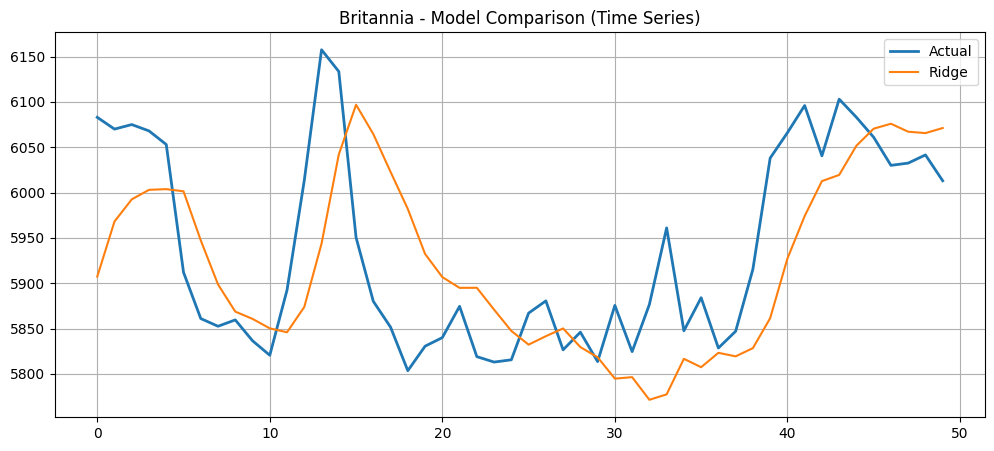

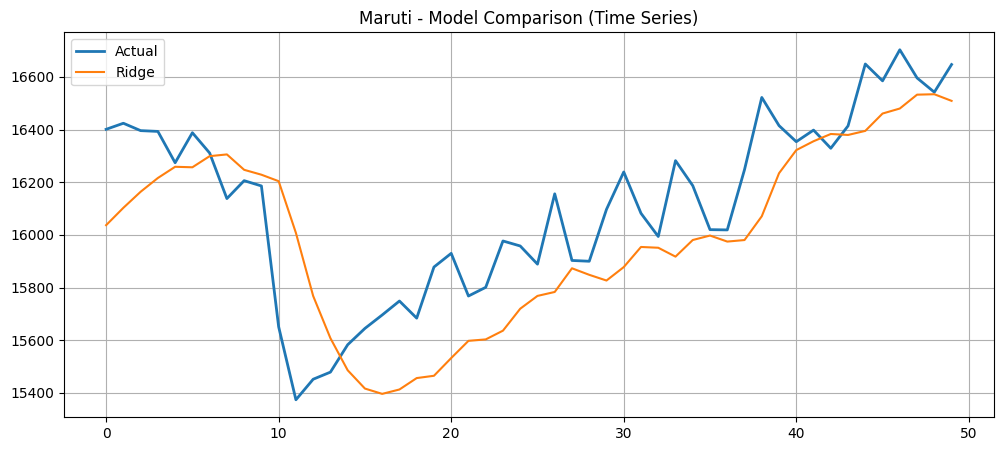

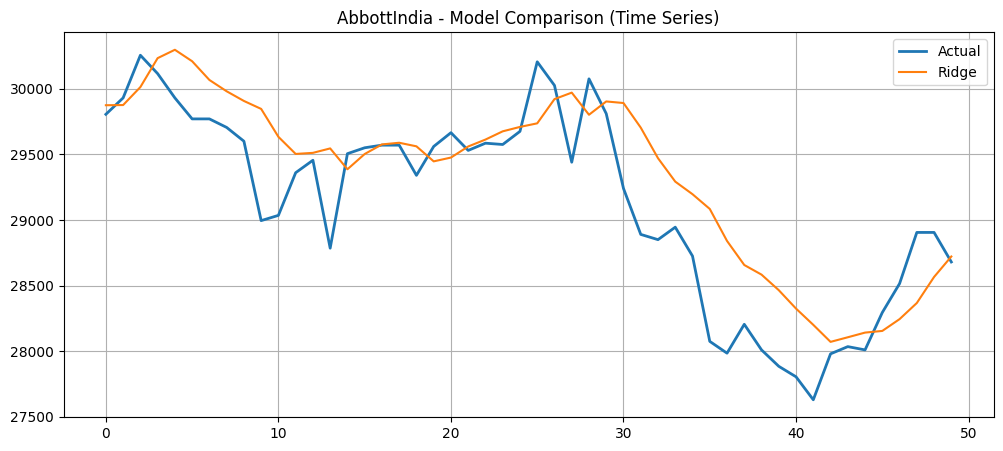

In [54]:
for name in stocks.keys():

    plt.figure(figsize=(12,5))

    actual_series = y_test_real[name][-50:]   # last 50 points
    ridge_series = ridge_predictions_real[name][-50:]
   # gru_series = gru_predictions_real[name][-50:]

    x = np.arange(len(actual_series))

    plt.plot(x, actual_series, label="Actual", linewidth=2)
    plt.plot(x, ridge_series, label="Ridge")
    #plt.plot(x, gru_series, label="GRU")

    plt.title(f"{name} - Model Comparison (Time Series)")
    plt.legend()
    plt.grid(True)
    plt.show()

In [55]:
comparison_table = []

for name in stocks.keys():

    predicted = ridge_predictions_real[name][-1]
    actual = live_prices[name]

    error_pct = abs(predicted - actual) / actual * 100

    comparison_table.append([name, predicted, actual, error_pct])

df_final = pd.DataFrame(
    comparison_table,
    columns=["Stock", "Predicted", "Live Price", "Error %"]
)

df_final

,Stock,Predicted,Live Price,Error %
0,Oracle,201.550539,157.529999,27.944227
1,ICICI,1361.342775,1373.599976,0.892341
2,Britannia,6071.193355,5262.500000,15.367095
3,Maruti,16509.013788,13248.000000,24.615140
4,AbbottIndia,28721.602931,25595.000000,12.215679
